In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))


fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000
fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["fresh", "infected"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ fresh: 3499 train, 1000 val, 501 test
✅ infected: 3499 train, 1000 val, 501 test

🎯 Dataset split completed!


# **CNN**

Classes: ['fresh', 'infected']
Found 6998 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 1002 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,202 (98.49 MB)

 Trainable params: 25,817,986 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 134s 559ms/step - accuracy: 0.9591 - loss: 0.1166 - val_accuracy: 0.5000 - val_loss: 1.9778
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 112s 508ms/step - accuracy: 0.9900 - loss: 0.0378 - val_accuracy: 0.6555 - val_loss: 0.5945
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 108s 489ms/step - accuracy: 0.9956 - loss: 0.0204 - val_accuracy: 0.9970 - val_loss: 0.0132
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 483ms/step - accuracy: 0.9934 - loss: 0.0221 - val_accuracy: 0.9925 - val_loss: 0.0165
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 481ms/step - accuracy: 0.9961 - loss: 0.0162 - val_accuracy: 0.9960 - val_loss: 0.0165
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 476ms/step - accuracy: 0.9986 - loss: 0.0086 - val_accuracy: 0.9965 - val_loss: 0.0131
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 483ms/step - accuracy: 0.9989 - loss: 0.0078 - val_accuracy: 0.9980 - val_loss: 0.0056
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 486ms/step - accuracy: 0.9980 -

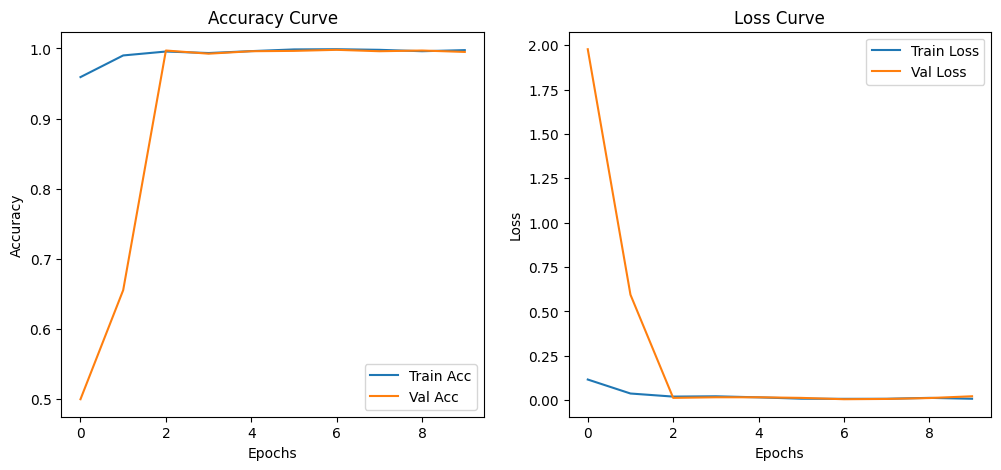

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step


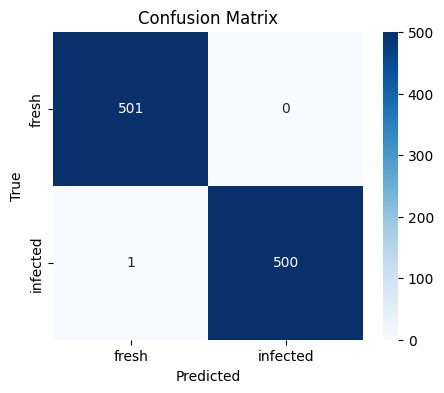


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    1.0000    0.9990       501
    infected     1.0000    0.9980    0.9990       501

    accuracy                         0.9990      1002
   macro avg     0.9990    0.9990    0.9990      1002
weighted avg     0.9990    0.9990    0.9990      1002


🔹 Macro Average Accuracy (Precision Avg) : 0.9990
🔹 Overall Test Accuracy: 0.9990


In [ ]:
# --------------------------
# CNN (Fresh vs Infected) - Complete with Macro Accuracy
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10   # change if needed

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Refined CNN Model
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"  # future-proof format
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Loss & Accuracy
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data (with Macro Accuracy)
# --------------------------
y_pred = model_cnn.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy (Average Precision) & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg) : {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,650 (56.26 MB)

 Trainable params: 32,962 (128.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 149s 616ms/step - accuracy: 0.7131 - loss: 0.5595 - val_accuracy: 0.9820 - val_loss: 0.3171
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 114s 521ms/step - accuracy: 0.9493 - loss: 0.2531 - val_accuracy: 0.9880 - val_loss: 0.1516
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 110s 504ms/step - accuracy: 0.9806 - loss: 0.1348 - val_accuracy: 0.9910 - val_loss: 0.0882
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 145s 517ms/step - accuracy: 0.9870 - loss: 0.0880 - val_accuracy: 0.9910 - val_loss: 0.0604
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 515ms/step - accuracy: 0.9914 - loss: 0.0625 - val_accuracy: 0.9925 - val_loss: 0.0449
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 112s 510ms/step - accuracy: 0.9916 - loss: 0.0494 - val_accuracy: 0.9935 - val_loss: 0.0357
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 112s 509ms/step - accuracy: 0.9944 - loss: 0.0385 - val_accuracy: 0.9940 - val_loss: 0.0292
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 124s 565ms/step - accuracy: 0.9941 -

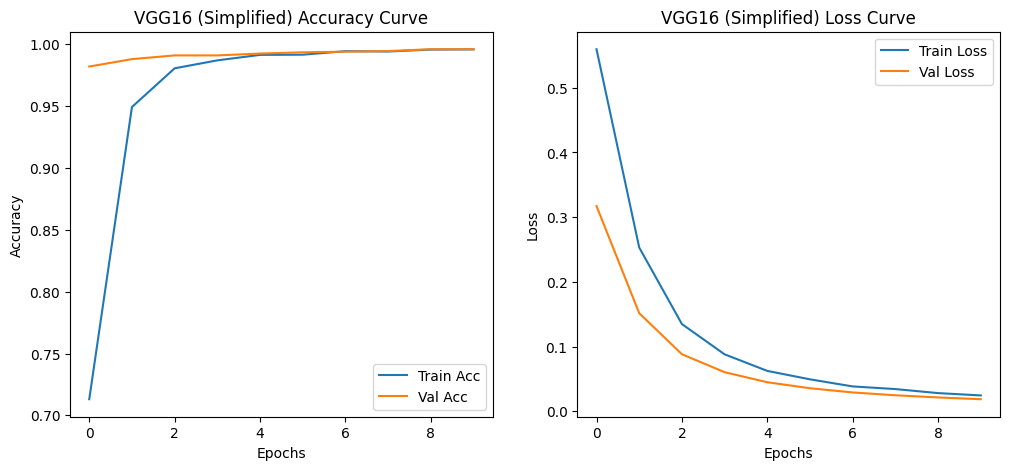

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 611ms/step


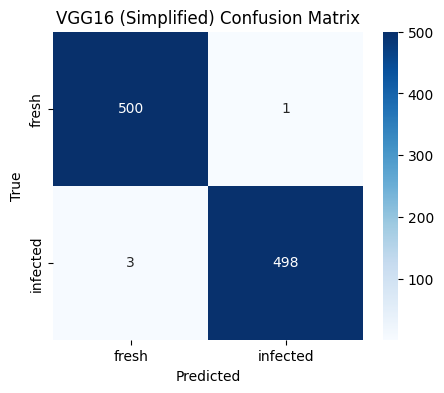


VGG16 (Simplified) Classification Report:

              precision    recall  f1-score   support

       fresh     0.9940    0.9980    0.9960       501
    infected     0.9980    0.9940    0.9960       501

    accuracy                         0.9960      1002
   macro avg     0.9960    0.9960    0.9960      1002
weighted avg     0.9960    0.9960    0.9960      1002

🔹 VGG16 (Simplified) Macro Average Accuracy: 0.9960
🔹 VGG16 (Simplified) Overall Test Accuracy: 0.9960


In [ ]:
# --------------------------
# VGG16 (Simplified Head) - Fresh vs Infected
# --------------------------
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ✅ Base Model with smaller image size
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)        # শুধু pooling
x = Dense(64, activation="relu")(x)    # ছোট dense layer
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation="softmax")(x)

model_vgg16_simple = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Compile
model_vgg16_simple.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg16_simple.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_vgg16_simple.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)
]

# --------------------------
# Train
# --------------------------
history = model_vgg16_simple.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# --------------------------
# Plot Curves
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("VGG16 (Simplified) Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("VGG16 (Simplified) Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation
# --------------------------
y_pred = model_vgg16_simple.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG16 (Simplified) Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nVGG16 (Simplified) Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# Macro & Overall Accuracy
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)

print(f"🔹 VGG16 (Simplified) Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 VGG16 (Simplified) Overall Test Accuracy: {overall_acc:.4f}")


In [ ]:
import numpy as np

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# 1. FEATURE EXTRACTOR (from trained VGG16)
# --------------------------
feature_extractor = Model(
    inputs=model_vgg16_simple.input,
    outputs=model_vgg16_simple.layers[-2].output  # Dense(64) layer output
)

# --------------------------
# 2. FEATURE EXTRACTION FUNCTION
# --------------------------
def extract_features(model, generator):
    features, labels = [], []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = model.predict(x_batch, verbose=0)

        features.append(feat)
        labels.append(y_batch)

    return np.vstack(features), np.hstack(labels)

print("Extracting features from VGG16...")

X_train, y_train = extract_features(feature_extractor, train_gen)
X_test, y_test = extract_features(feature_extractor, test_gen)

# --------------------------
# 3. ML CLASSIFIERS
# --------------------------
classifiers = {
    "SVM": SVC(kernel='linear'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, eval_metric='mlogloss'),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), max_iter=500)
}

# --------------------------
# 4. TRAIN + EVALUATION (DIRECT)
# --------------------------
results = {}

for name, clf in classifiers.items():
    print(f"\n===== {name} =====")

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)

    results[name] = [precision, recall, f1, acc]

    print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

# --------------------------
# 5. RESULT TABLE
# --------------------------
import pandas as pd

df = pd.DataFrame(results, index=["Precision", "Recall", "F1", "Accuracy"]).T

print("\n🔹 FINAL ML RESULTS:\n")
print(df)

Extracting features from VGG16...

===== SVM =====
Precision=0.9970, Recall=0.9970, F1=0.9970, Accuracy=0.9970

===== KNN =====
Precision=0.9960, Recall=0.9960, F1=0.9960, Accuracy=0.9960

===== RandomForest =====
Precision=0.9970, Recall=0.9970, F1=0.9970, Accuracy=0.9970

===== LogisticRegression =====
Precision=0.9960, Recall=0.9960, F1=0.9960, Accuracy=0.9960

===== DecisionTree =====
Precision=0.9960, Recall=0.9960, F1=0.9960, Accuracy=0.9960

===== GradientBoosting =====
Precision=0.9970, Recall=0.9970, F1=0.9970, Accuracy=0.9970

===== XGBoost =====
Precision=0.9970, Recall=0.9970, F1=0.9970, Accuracy=0.9970

===== LightGBM =====
[LightGBM] [Info] Number of positive: 3499, number of negative: 3499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12324
[LightGBM] [Info] Number 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Precision=0.9980, Recall=0.9980, F1=0.9980, Accuracy=0.9980

===== ExtraTrees =====
Precision=0.9970, Recall=0.9970, F1=0.9970, Accuracy=0.9970

===== MLP =====
Precision=0.9980, Recall=0.9980, F1=0.9980, Accuracy=0.9980

🔹 FINAL ML RESULTS:

                    Precision    Recall        F1  Accuracy
SVM                  0.997024  0.997006  0.997006  0.997006
KNN                  0.996016  0.996008  0.996008  0.996008
RandomForest         0.997024  0.997006  0.997006  0.997006
LogisticRegression   0.996016  0.996008  0.996008  0.996008
DecisionTree         0.996040  0.996008  0.996008  0.996008
GradientBoosting     0.997024  0.997006  0.997006  0.997006
XGBoost              0.997024  0.997006  0.997006  0.997006
LightGBM             0.998012  0.998004  0.998004  0.998004
ExtraTrees           0.997024  0.997006  0.997006  0.997006
MLP                  0.998012  0.998004  0.998004  0.998004


Classes: ['fresh', 'infected']
Found 6998 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 1002 images belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,481,858 (101.02 MB)

 Trainable params: 26,481,090 (101.02 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 253s 927ms/step - accuracy: 0.9506 - loss: 0.1501 - val_accuracy: 0.5000 - val_loss: 3.1980
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 163s 743ms/step - accuracy: 0.9819 - loss: 0.0678 - val_accuracy: 0.9945 - val_loss: 0.0207
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 162s 737ms/step - accuracy: 0.9867 - loss: 0.0559 - val_accuracy: 0.7165 - val_loss: 0.9603
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 163s 742ms/step - accuracy: 0.9856 - loss: 0.0490 - val_accuracy: 0.9885 - val_loss: 0.0338
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 162s 737ms/step - accuracy: 0.9890 - loss: 0.0362 - val_accuracy: 0.9905 - val_loss: 0.0416
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 203s 742ms/step - accuracy: 0.9886 - loss: 0.0422 - val_accuracy: 0.8370 - val_loss: 0.4353
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 163s 745ms/step - accuracy: 0.9893 - loss: 0.0370 - val_accuracy: 0.9960 - val_loss: 0.0240


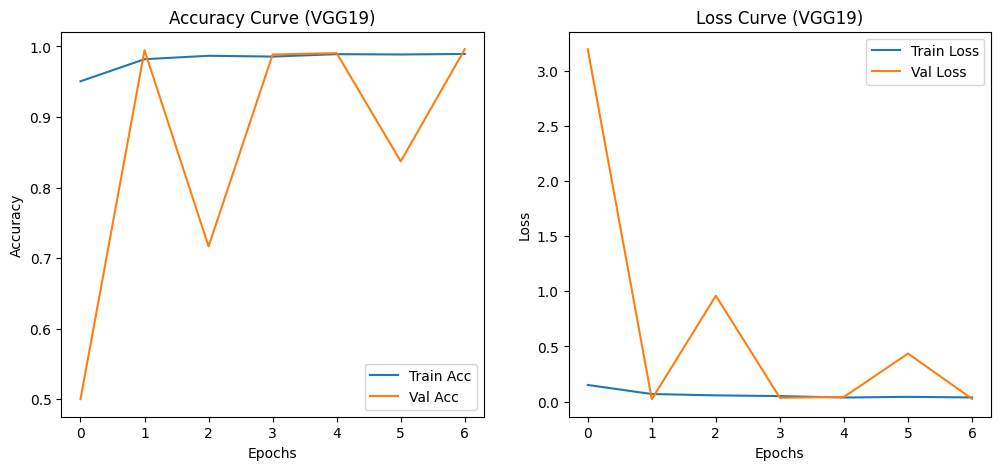

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 483ms/step


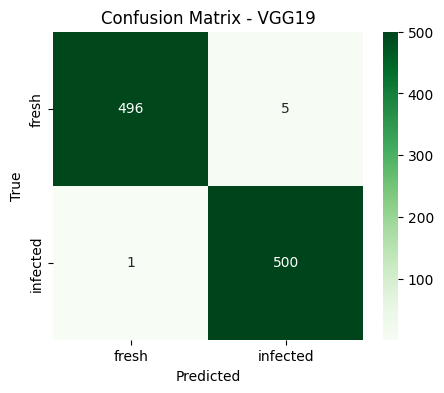


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    0.9900    0.9940       501
    infected     0.9901    0.9980    0.9940       501

    accuracy                         0.9940      1002
   macro avg     0.9940    0.9940    0.9940      1002
weighted avg     0.9940    0.9940    0.9940      1002


🔹 Macro Average Accuracy (Precision Avg): 0.9940
🔹 Overall Test Accuracy: 0.9940


In [ ]:
# --------------------------
# VGG19 (Fresh vs Infected) - Balanced Accuracy Version
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10   # adjust if needed

class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# VGG19 Model (No Pretrained Weights)
# --------------------------
base_vgg = VGG19(weights=None, include_top=False, input_shape=(224, 224, 3))

model_vgg19 = Sequential([
    base_vgg,
    Flatten(),
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')
])

model_vgg19.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_vgg19_model.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Accuracy & Loss
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve (VGG19)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve (VGG19)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data (with Macro Accuracy)
# --------------------------
y_pred = model_vgg19.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG19")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy (Average Precision) & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg): {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,946 (92.11 MB)

 Trainable params: 558,466 (2.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 150s 608ms/step - accuracy: 0.7476 - loss: 0.5308 - val_accuracy: 0.8315 - val_loss: 0.5597
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 516ms/step - accuracy: 0.8711 - loss: 0.3137 - val_accuracy: 0.8775 - val_loss: 0.3567
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 514ms/step - accuracy: 0.9051 - loss: 0.2348 - val_accuracy: 0.8950 - val_loss: 0.2449
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 524ms/step - accuracy: 0.9120 - loss: 0.2165 - val_accuracy: 0.8845 - val_loss: 0.2428
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 117s 533ms/step - accuracy: 0.9187 - loss: 0.1947 - val_accuracy: 0.9210 - val_loss: 0.1899
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 516ms/step - accuracy: 0.9257 - loss: 0.1783 - val_accuracy: 0.9105 - val_loss: 0.2092
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 130s 596ms/step - accuracy: 0.9328 - loss: 0.1681 - val_accuracy: 0.8515 - val_loss: 0.3221
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 109s 497ms/step - accuracy: 0.9334 -

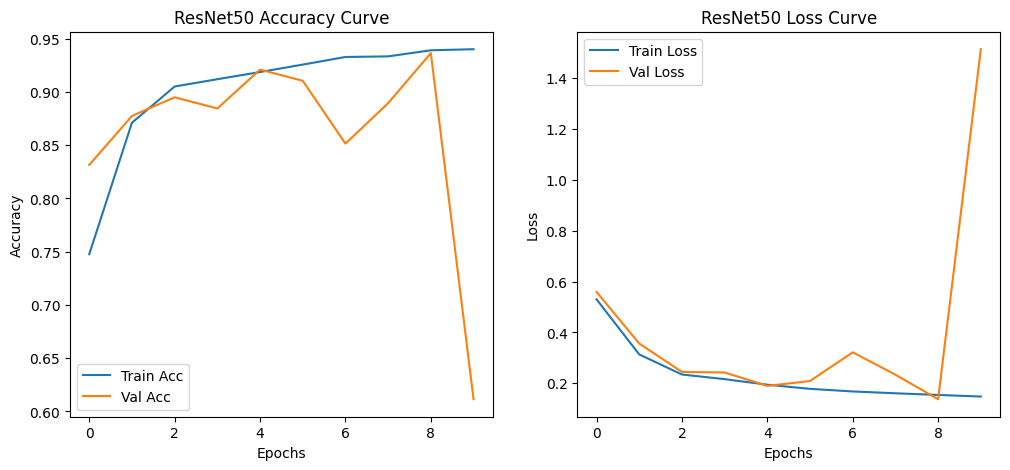

32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 536ms/step


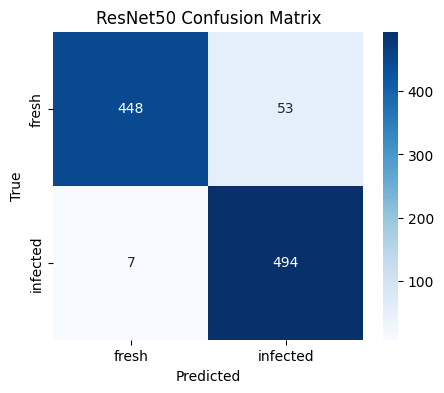


ResNet50 Classification Report:

              precision    recall  f1-score   support

       fresh     0.9846    0.8942    0.9372       501
    infected     0.9031    0.9860    0.9427       501

    accuracy                         0.9401      1002
   macro avg     0.9439    0.9401    0.9400      1002
weighted avg     0.9439    0.9401    0.9400      1002

🔹 ResNet50 Macro Average Accuracy: 0.9439
🔹 ResNet50 Overall Test Accuracy: 0.9401


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Base Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)
model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model_resnet.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()

# Callbacks
checkpoint_path = "best_resnet50.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train
history = model_resnet.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=callbacks)

# Plot curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("ResNet50 Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluation
y_pred = model_resnet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nResNet50 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 ResNet50 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 ResNet50 Overall Test Accuracy: {overall_acc:.4f}")


Classes: ['fresh', 'infected']
Found 6998 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 1002 images belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,334,594 (27.98 MB)

 Trainable params: 663,490 (2.53 MB)

 Non-trainable params: 6,671,104 (25.45 MB)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 223s 855ms/step - accuracy: 0.8149 - loss: 1.4954 - val_accuracy: 0.9890 - val_loss: 1.1146
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 141s 643ms/step - accuracy: 0.9544 - loss: 1.1048 - val_accuracy: 0.9980 - val_loss: 0.9329
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 141s 642ms/step - accuracy: 0.9804 - loss: 0.9340 - val_accuracy: 0.9985 - val_loss: 0.8323
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 648ms/step - accuracy: 0.9894 - loss: 0.8347 - val_accuracy: 0.9990 - val_loss: 0.7632
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 141s 646ms/step - accuracy: 0.9911 - loss: 0.7680 - val_accuracy: 0.9995 - val_loss: 0.7108
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 141s 639ms/step - accuracy: 0.9927 - loss: 0.7172 - val_accuracy: 1.0000 - val_loss: 0.6689
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 138s 631ms/step - accuracy: 0.9961 - loss: 0.6700 - val_accuracy: 1.0000 - val_loss: 0.6334
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 652ms/step - accuracy: 0.9977 -

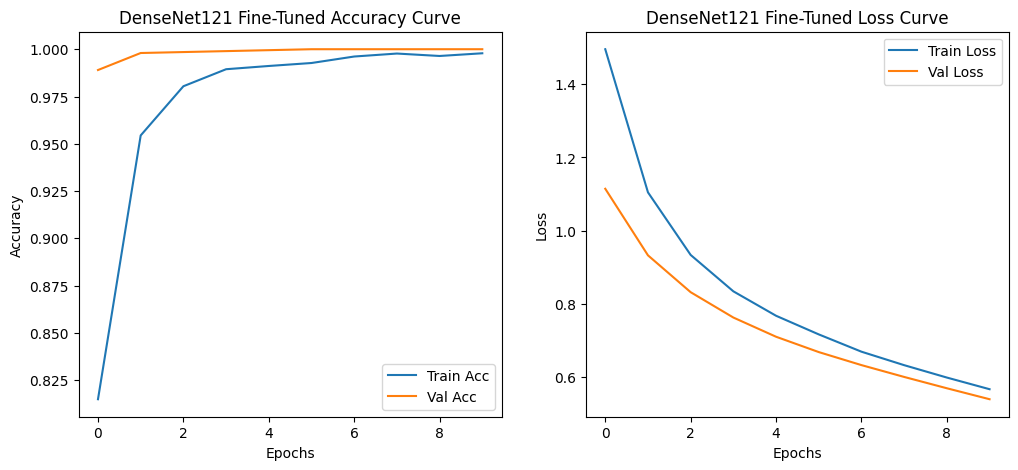

32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 811ms/step


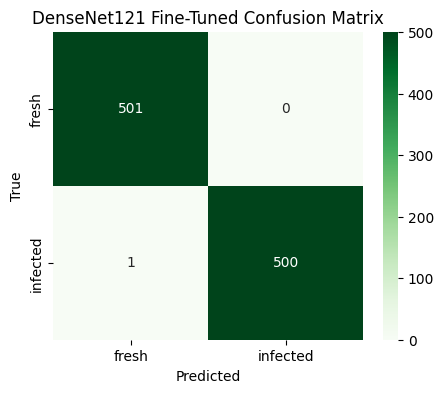


DenseNet121 Fine-Tuned Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    1.0000    0.9990       501
    infected     1.0000    0.9980    0.9990       501

    accuracy                         0.9990      1002
   macro avg     0.9990    0.9990    0.9990      1002
weighted avg     0.9990    0.9990    0.9990      1002

🔹 DenseNet121 Macro Average Accuracy: 0.9990
🔹 DenseNet121 Overall Test Accuracy: 0.9990


In [ ]:
# --------------------------
# Refined DenseNet121 (Target Accuracy ~95–98%)
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (128, 128)  # smaller image size to reduce overfitting
batch_size = 32
epochs = 10

class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (Stronger Augmentation)
# --------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Base DenseNet121 Model
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze most layers (only fine-tune last 20 layers)
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.6)(x)
x = Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.4)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model_densenet = Model(inputs=base_model.input, outputs=predictions)

# --------------------------
# Compile Model
# --------------------------
model_densenet.compile(
    optimizer=Adam(learning_rate=5e-5),  # smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_densenet.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_refined_densenet121_v2.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_densenet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Accuracy & Loss
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("DenseNet121 Fine-Tuned Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("DenseNet121 Fine-Tuned Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data
# --------------------------
y_pred = model_densenet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet121 Fine-Tuned Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nDenseNet121 Fine-Tuned Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 DenseNet121 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 DenseNet121 Overall Test Accuracy: {overall_acc:.4f}")


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction with DenseNet121
# --------------------------
# Assuming train_gen is the full dataset generator (images + labels)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3)) # Changed input_shape to (128, 128, 3)
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Function to extract features
def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting features from full dataset...")
X, y = extract_features(train_gen)

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

precisions, recalls, f1s, accuracies = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_fold, y_train_fold)
    y_pred_fold = clf.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_pred_fold, average='macro')
    recall = recall_score(y_val_fold, y_pred_fold, average='macro')
    f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
    acc = accuracy_score(y_val_fold, y_pred_fold)

    # Print fold metrics
    print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    # Save for overall average
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(acc)

# --------------------------
# Average metrics across folds
# --------------------------
print("\n===== 10-Fold CV Average Metrics =====")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall:    {np.mean(recalls):.4f}")
print(f"Macro F1-score:  {np.mean(f1s):.4f}")
print(f"Accuracy:        {np.mean(accuracies):.4f}")

Extracting features from full dataset...
Fold 1: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 2: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 3: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 4: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 5: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 6: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 7: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 8: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986

===== 10-Fold CV Average Metrics =====
Macro Precision: 0.9991
Macro Recall:    0.9991
Macro F1-score:  0.9991
Accuracy:        0.9991


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction (DenseNet121)
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3))
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting DenseNet121 features from dataset...")
X, y = extract_features(train_gen)  # use full dataset generator

# --------------------------
# Classifiers
# --------------------------
classifiers = {
    "SVM": SVC(kernel='linear', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), max_iter=500, random_state=42)
}

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    print(f"\n===== {name} 10-Fold CV =====")
    precisions, recalls, f1s, accuracies = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        clf.fit(X_train_fold, y_train_fold)
        y_pred_fold = clf.predict(X_val_fold)

        precision = precision_score(y_val_fold, y_pred_fold, average='macro')
        recall = recall_score(y_val_fold, y_pred_fold, average='macro')
        f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
        acc = accuracy_score(y_val_fold, y_pred_fold)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracies.append(acc)

        print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    print(f"\n{name} 10-Fold Average: Precision={np.mean(precisions):.4f}, Recall={np.mean(recalls):.4f}, F1={np.mean(f1s):.4f}, Accuracy={np.mean(accuracies):.4f}")

Extracting DenseNet121 features from dataset...

===== SVM 10-Fold CV =====
Fold 1: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 2: Precision=0.9972, Recall=0.9971, F1=0.9971, Accuracy=0.9971
Fold 3: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 4: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 5: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 6: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 7: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 8: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 9: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 10: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986

SVM 10-Fold Average: Precision=0.9987, Recall=0.9987, F1=0.9987, Accuracy=0.9987

===== KNN 10-Fold CV =====
Fold 1: Precision=0.9958, Recall=0.9957, F1=0.9957, Accuracy=0.9957
Fold 2: Precision=0.9916, Recall=0.9914, F1=0.9914, Accuracy=0.99

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:55:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1: Precision=0.9971, Recall=0.9971, F1=0.9971, Accuracy=0.9971


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:55:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986


...

Fold 8: Precision=0.9972, Recall=0.9971, F1=0.9971, Accuracy=0.9971
[LightGBM] [Info] Number of positive: 3150, number of negative: 3149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.155019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 6299, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500079 -> initscore=0.000318
[LightGBM] [Info] Start training from score 0.000318
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
[LightGBM] [Info] Number of positive: 3149, number of negative: 3150
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.120661 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 6299, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499921 -> initscore=-0.000318
[LightGBM] [Info] Start training from score -0.000318
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 10: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986

LightGBM 10-Fold Average: Precision=0.9982, Recall=0.9981, F1=0.9981, Accuracy=0.9981

===== ExtraTrees 10-Fold CV =====
Fold 1: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 2: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 3: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 4: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 5: Precision=0.9971, Recall=0.9971, F1=0.9971, Accuracy=0.9971
Fold 6: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 7: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 8: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9986, Recall=0.9986, F1=0.9986, Accuracy=0.9986

ExtraTrees 10-Fold Average: Precision=0.9990, Recall=0.9990, F1=0.9990, Accuracy=0.9990

===== MLP 10-Fold CV =====
Fold 1: Pre

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 162s 525ms/step - accuracy: 0.4914 - loss: 0.6979 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 458ms/step - accuracy: 0.5025 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 431ms/step - accuracy: 0.5044 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 435ms/step - accuracy: 0.4997 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 418ms/step - accuracy: 0.5009 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 447ms/step - accuracy: 0.5110 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 434ms/step - accuracy: 0.4999 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 107s 427ms/step - accuracy: 0.4988 -

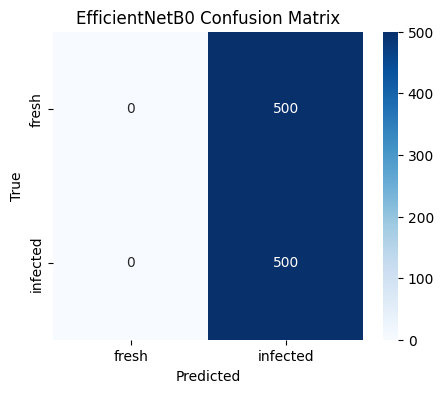

              precision    recall  f1-score   support

       fresh     0.0000    0.0000    0.0000       500
    infected     0.5000    1.0000    0.6667       500

    accuracy                         0.5000      1000
   macro avg     0.2500    0.5000    0.3333      1000
weighted avg     0.2500    0.5000    0.3333      1000

🔹 Macro Average Accuracy: 0.2500
🔹 Overall Test Accuracy: 0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf
import os

# Paths & parameters
output_dir = "/content/Final_split"
img_size = (224, 224)

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))

# Base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)   # Increase dense layer size
x = Dropout(0.3)(x)                    # Reduce dropout rate
predictions = Dense(len(class_names), activation='softmax')(x)

model_efficient = Model(inputs=base_model.input, outputs=predictions)

# Freeze base
for layer in base_model.layers:
    layer.trainable = False

# Compile
model_efficient.compile(optimizer=Adam(1e-4),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Train
history = model_efficient.fit(train_gen, validation_data=val_gen, epochs=10)

# Evaluate
y_pred = model_efficient.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

# Classification report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")